### Évaluation des modèles CNN sur le dataset CUB-200 (Bobolink vs Indigo Bunting)
Ce notebook compare les performances de deux modèles CNN :

    - CNNWithSeamCarving : intègre une opération de pooling basée sur le Seam Carving,

    - CNNWithMaxPooling : utilise un MaxPooling classique.

L'évaluation est réalisée sur un sous-ensemble du dataset Caltech-UCSD Birds 200 (CUB-200-2011), limité à deux classes :

    - Bobolink

    - Indigo Bunting

Chaque classe est représentée par un maximum de 80 images d'entraînement et 20 images de test. Les performances sont mesurées via :

    - accuracy globale

    - précision / rappel / f1-score

    - affichage des images mal classées

L'objectif est de reproduire les expériences décrites dans l'article "Seam Carving as Feature Pooling in CNN" et d'observer dans quelles conditions le Seam Carving peut apporter un avantage sur MaxPooling.

In [1]:
# Importations
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from seam_carving_for_CNN import CNNWithSeamCarving, CNNWithMaxPooling

In [2]:
# Dataset personnalisé

class CUBSubsetDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB").resize((32, 32))
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

In [ ]:
# Parser les fichiers de CUB

CUB_ROOT = "../CUB_200_2011/CUB_200_2011" # Chemin vers le dossier CUB
images_dir = os.path.join(CUB_ROOT, "images")

# Lecture des fichiers
images_df = pd.read_csv(os.path.join(CUB_ROOT, "images.txt"), sep=" ", names=["img_id", "filepath"])
labels_df = pd.read_csv(os.path.join(CUB_ROOT, "image_class_labels.txt"), sep=" ", names=["img_id", "class_id"])
split_df = pd.read_csv(os.path.join(CUB_ROOT, "train_test_split.txt"), sep=" ", names=["img_id", "is_train"])
classes_df = pd.read_csv(os.path.join(CUB_ROOT, "classes.txt"), sep=" ", names=["class_id", "class_name"])

# Fusion des infos
df = images_df.merge(labels_df, on="img_id").merge(split_df, on="img_id")

# Classes 14 et 15 → indexés 14 et 15 dans le fichier, mais 0-based → classe 13 et 14
target_classes = [14, 15]
df = df[df["class_id"].isin(target_classes)]

# Remapper classes en 0 et 1
class_map = {14: 0, 15: 1}
df["label"] = df["class_id"].map(class_map)

# Générer les chemins complets
df["path"] = df["filepath"].apply(lambda x: os.path.join(images_dir, x))

# Échantillons : Adapter le nombre d'échantillons selon la disponibilité
train_paths, train_labels = [], []
test_paths, test_labels = [], []

for cls in [0, 1]:
    # Compter le nombre d'échantillons disponibles
    train_available = len(df[(df["label"] == cls) & (df["is_train"] == 1)])
    test_available = len(df[(df["label"] == cls) & (df["is_train"] == 0)])
    
    # Ajuster les tailles d'échantillons
    train_size = min(60, train_available)
    test_size = min(5, test_available)
    
    print(f"Classe {cls}: {train_size} échantillons d'entraînement, {test_size} échantillons de test")
    
    train_samples = df[(df["label"] == cls) & (df["is_train"] == 1)].sample(n=train_size, random_state=42)
    test_samples = df[(df["label"] == cls) & (df["is_train"] == 0)].sample(n=test_size, random_state=42)

    train_paths.extend(train_samples["path"].tolist())
    train_labels.extend(train_samples["label"].tolist())

    test_paths.extend(test_samples["path"].tolist())
    test_labels.extend(test_samples["label"].tolist())

Classe 0: 30 échantillons d'entraînement, 5 échantillons de test
Classe 1: 30 échantillons d'entraînement, 5 échantillons de test


In [7]:
# Création des DataLoaders
transform = transforms.ToTensor()
trainset = CUBSubsetDataset(train_paths, train_labels, transform)
testset = CUBSubsetDataset(test_paths, test_labels, transform)

trainloader = DataLoader(trainset, batch_size=1, shuffle=True)
testloader = DataLoader(testset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# Fonction d'évaluation
def evaluate_model(model, name):
    model = model.to(device)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in testloader:
            x = x.to(device)
            out = model(x)
            out = out.view(x.size(0), -1)[:, :2]
            _, pred = torch.max(out, 1)
            all_preds.append(pred.item())
            all_labels.append(y.item())

    print(f"\\n🔍 Rapport de classification pour {name} :")
    print(classification_report(all_labels, all_preds, target_names=["Bobolink", "Indigo_Bunting"]))

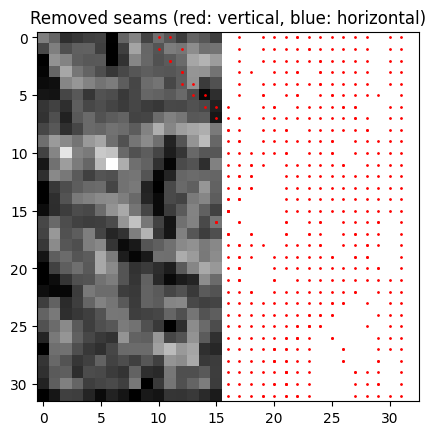

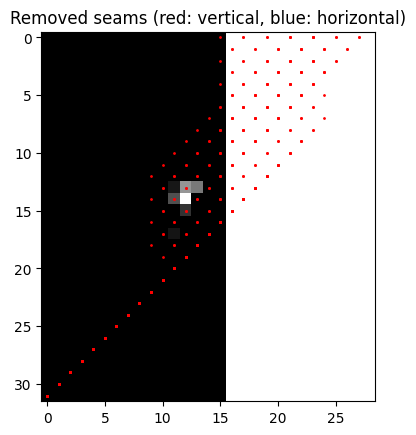

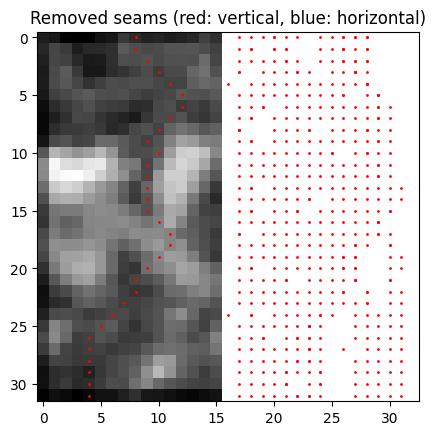

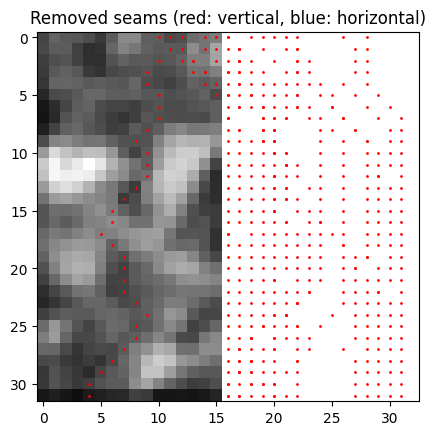

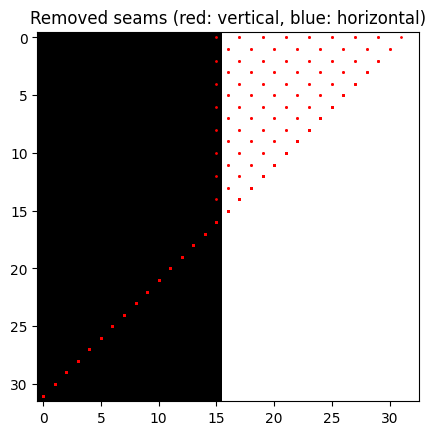

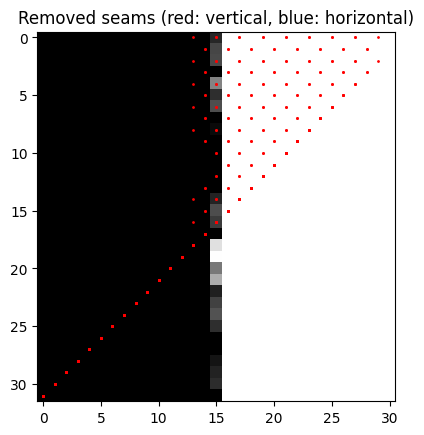

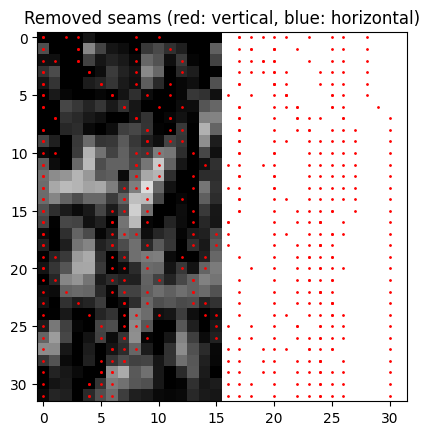

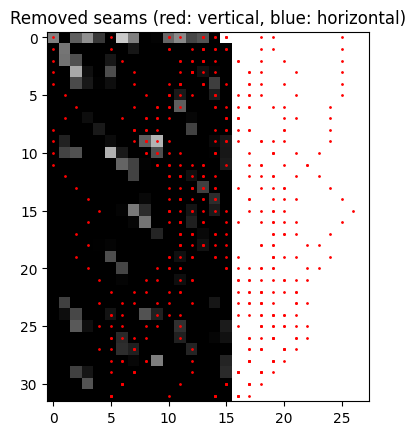

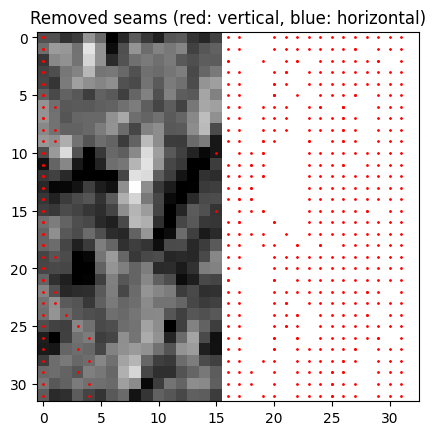

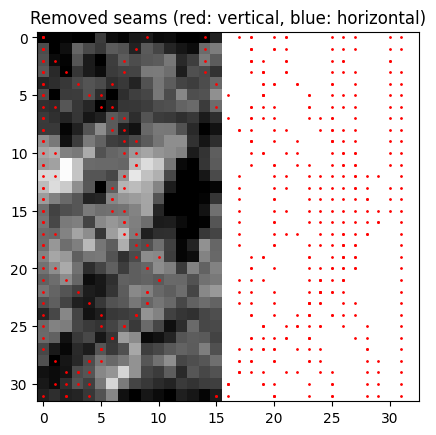

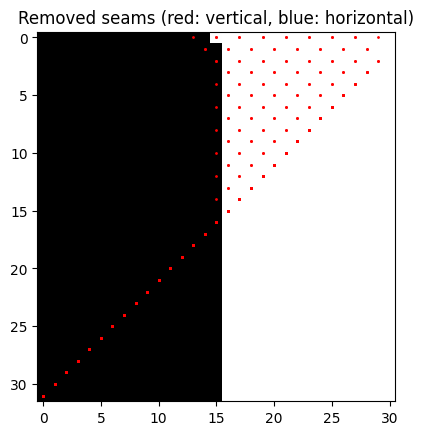

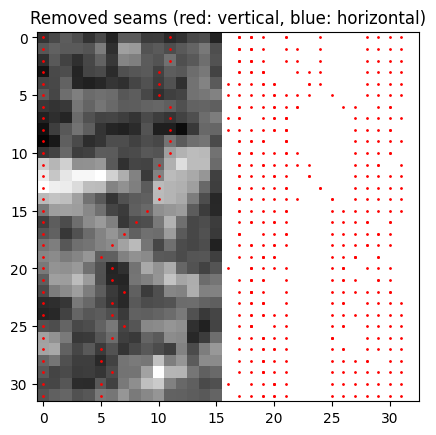

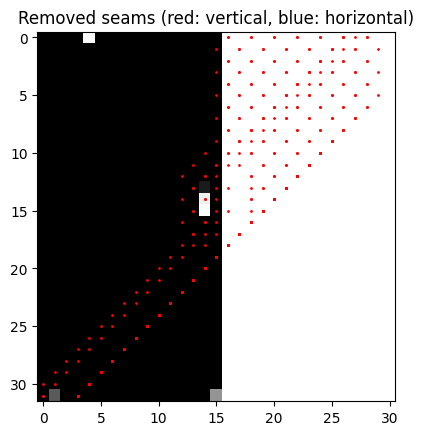

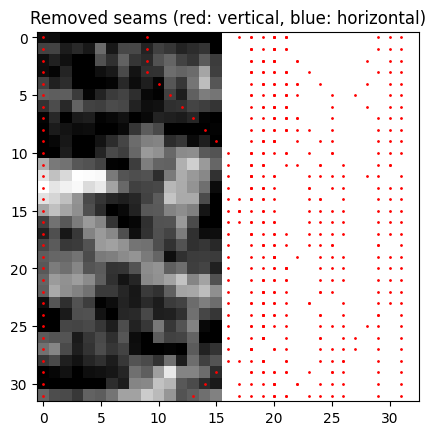

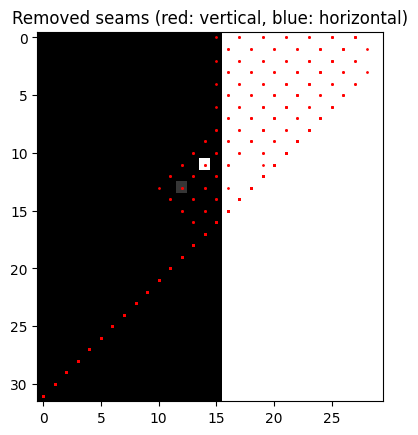

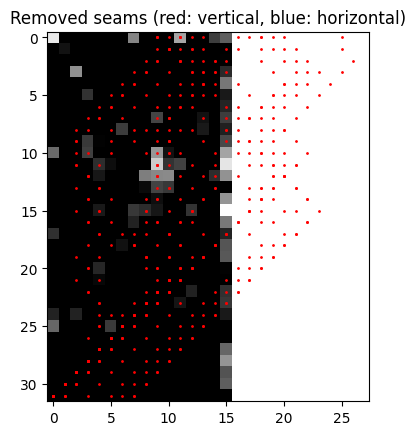

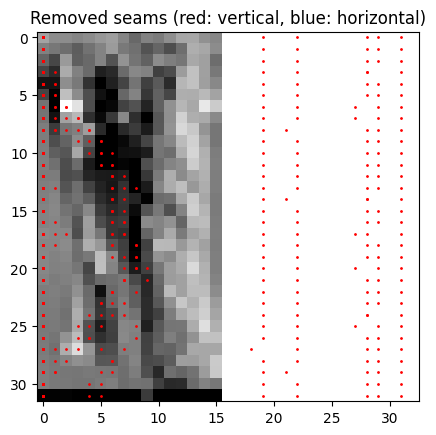

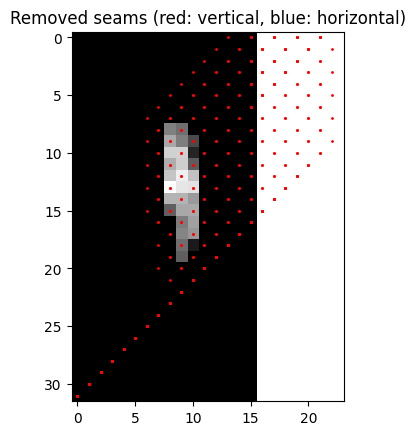

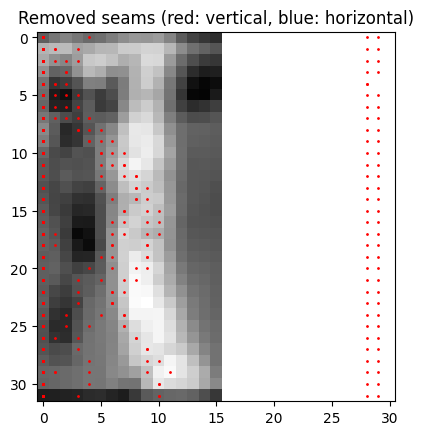

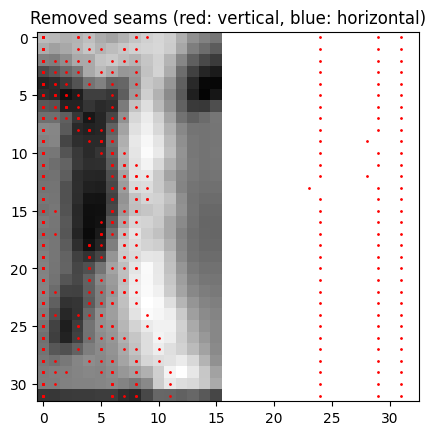

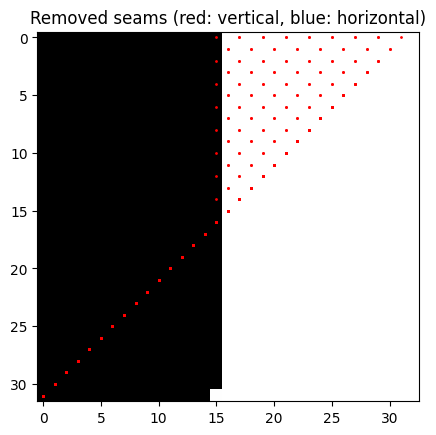

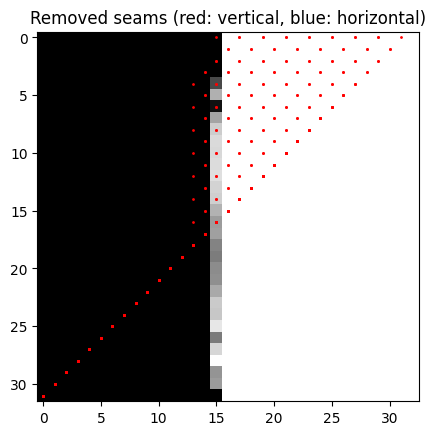

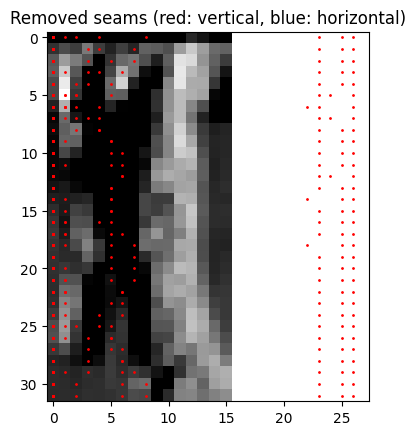

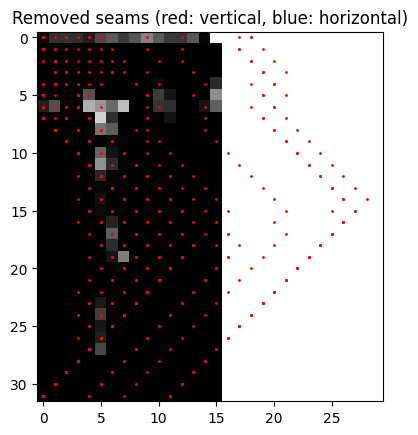

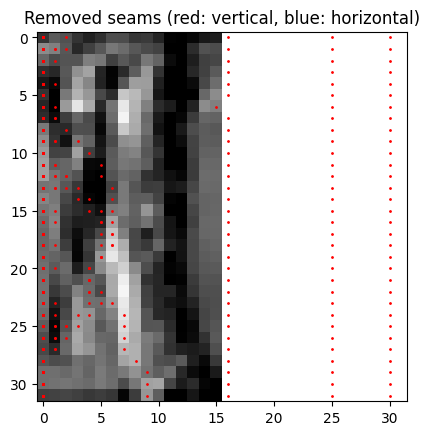

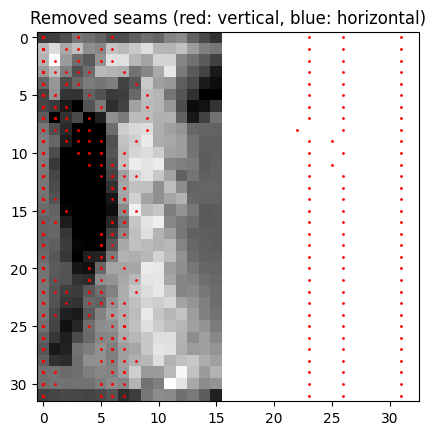

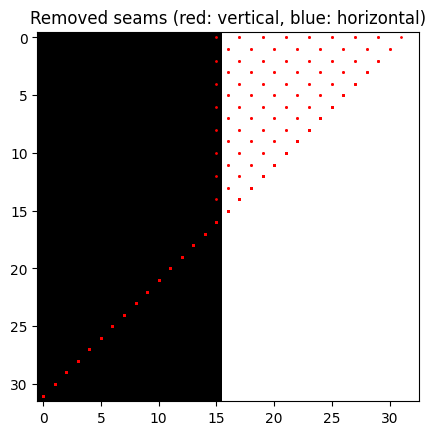

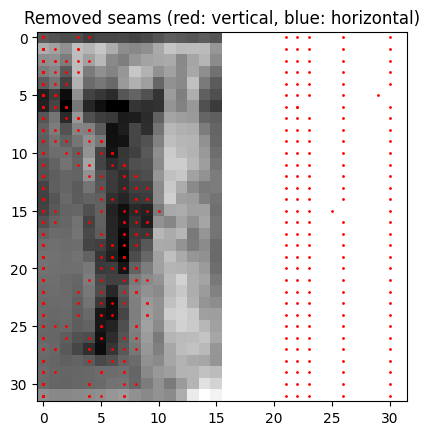

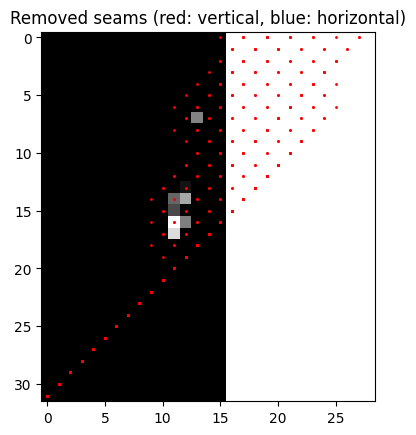

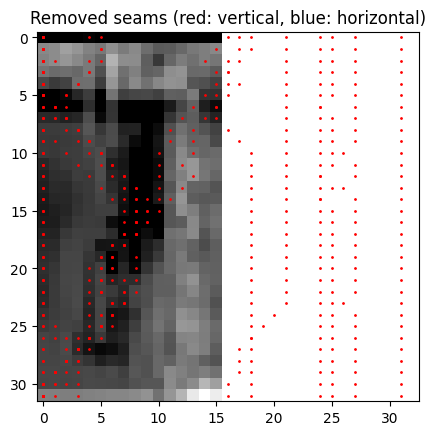

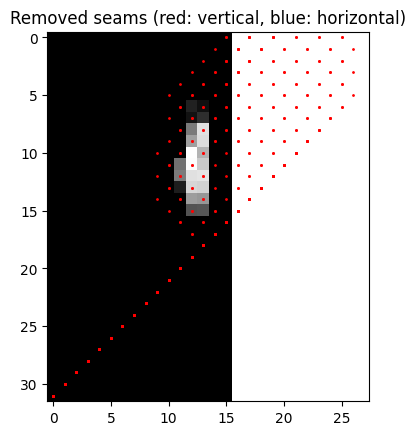

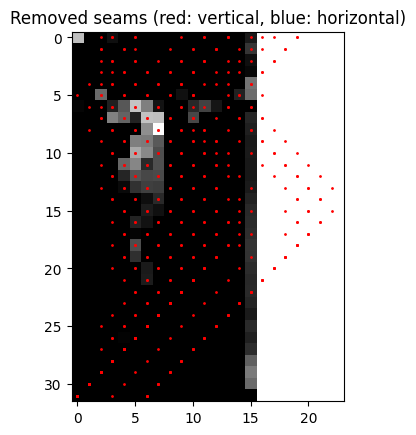

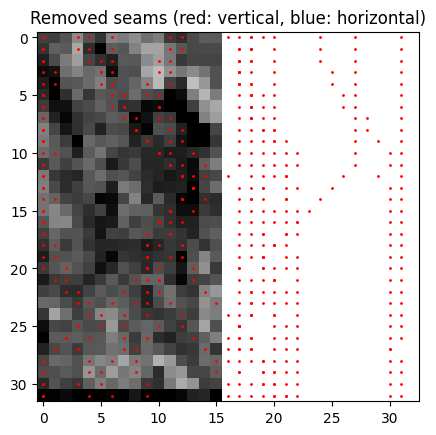

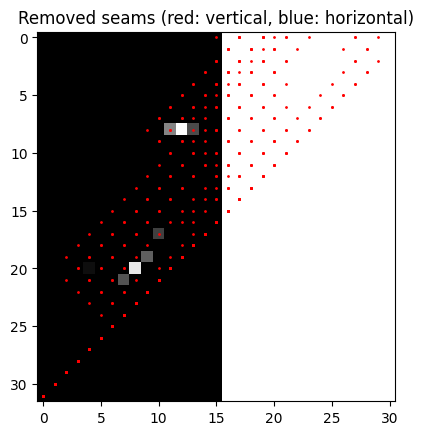

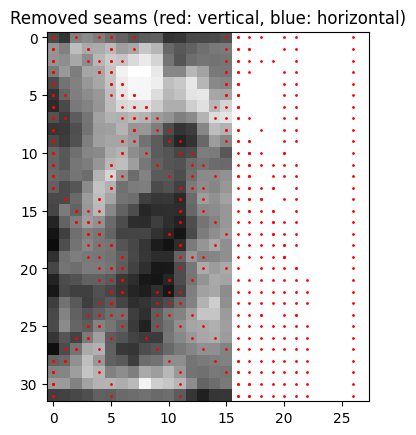

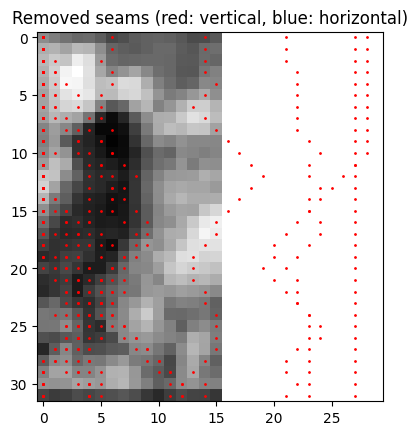

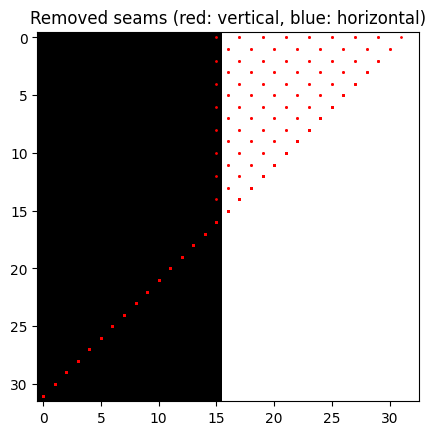

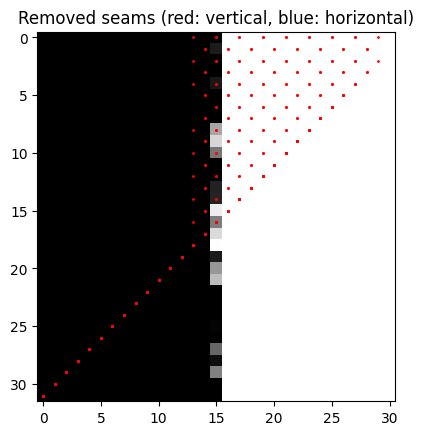

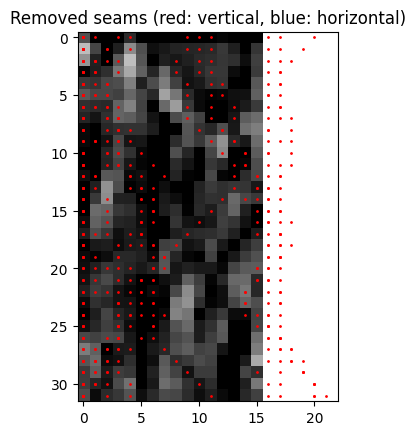

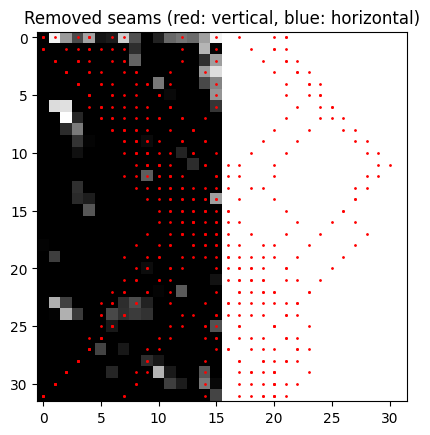

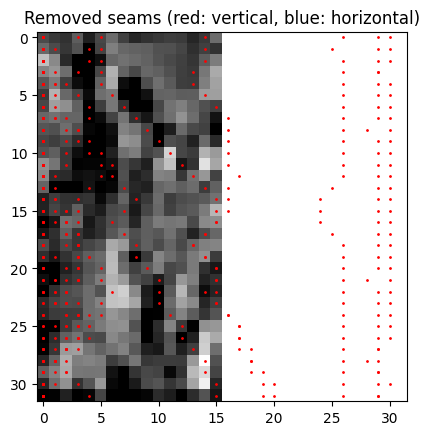

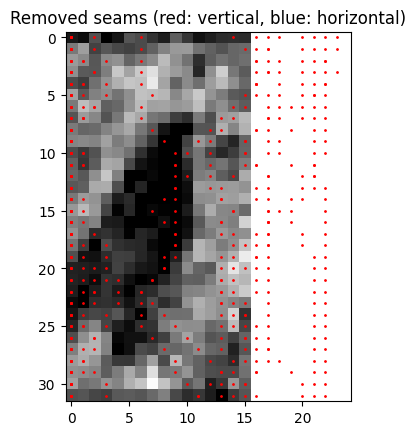

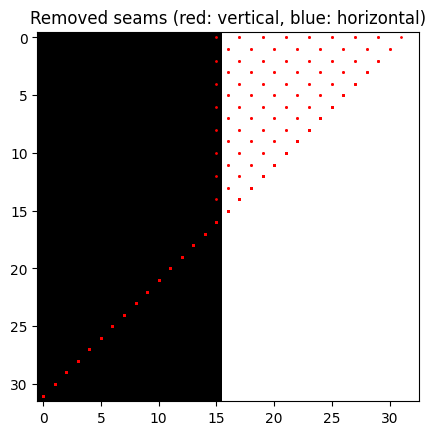

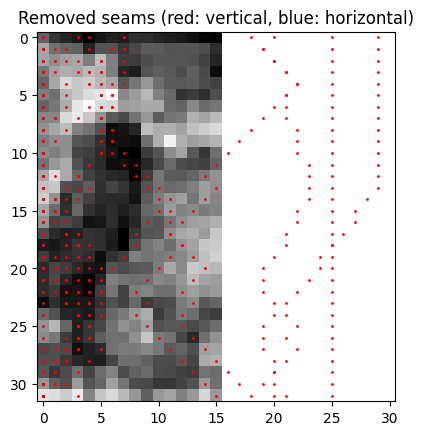

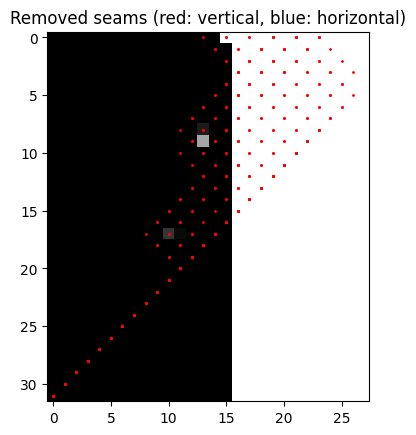

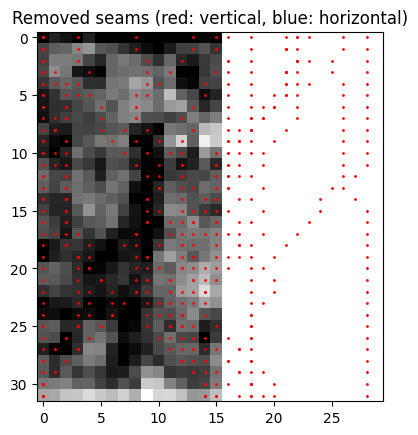

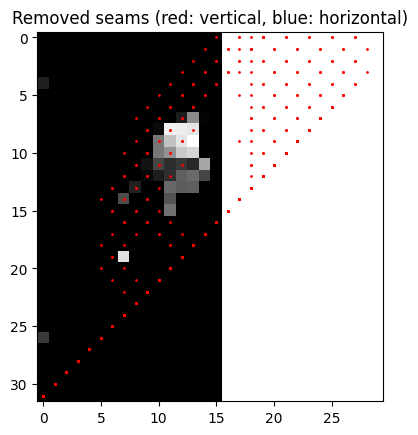

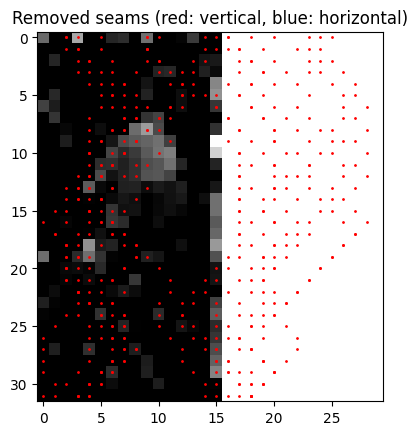

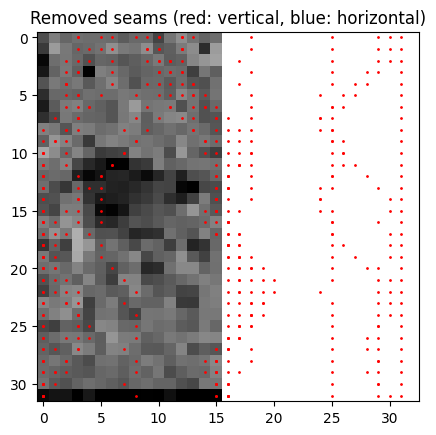

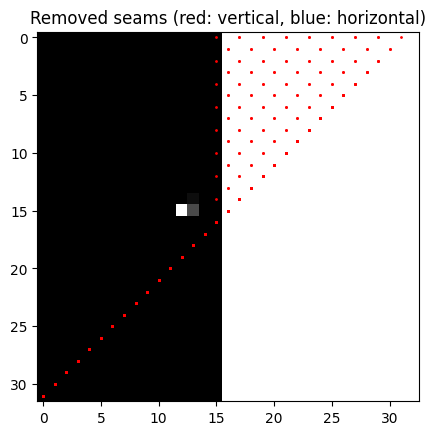

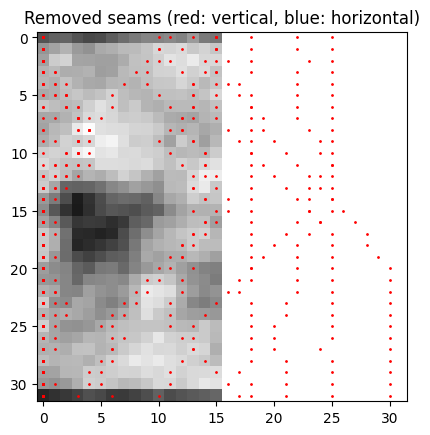

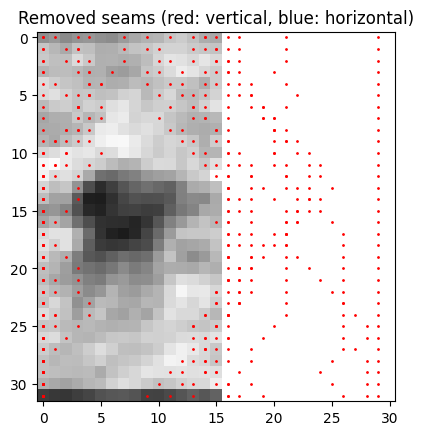

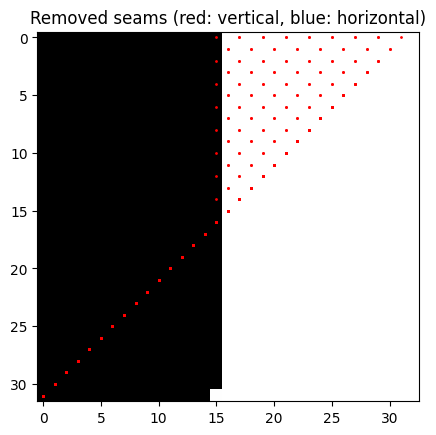

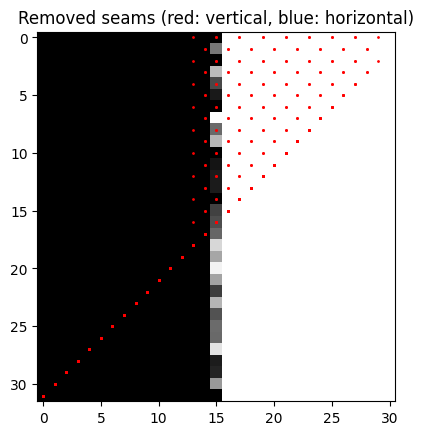

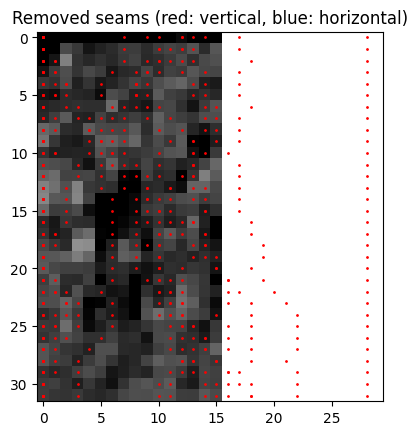

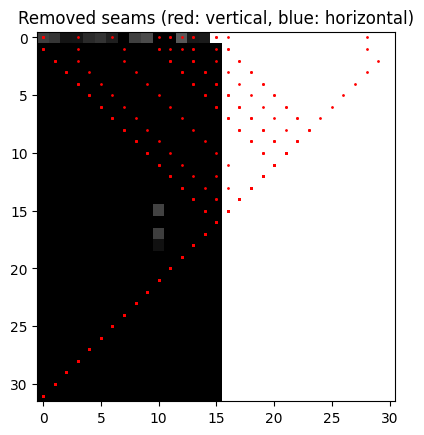

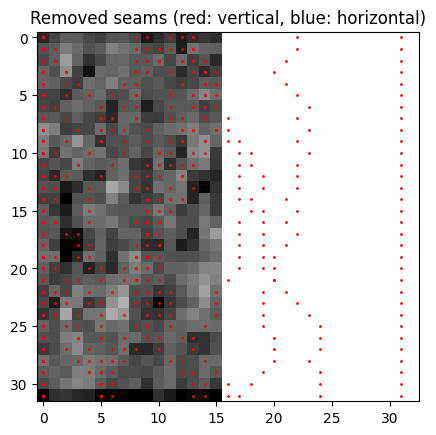

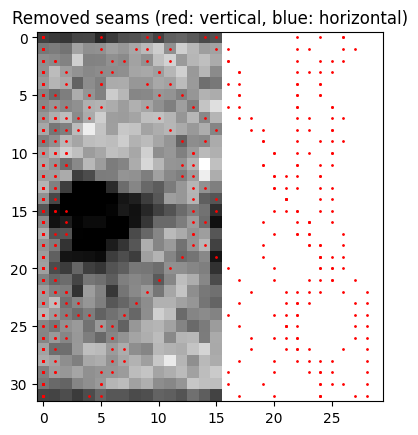

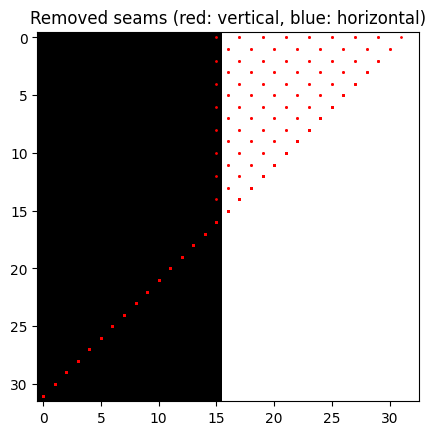

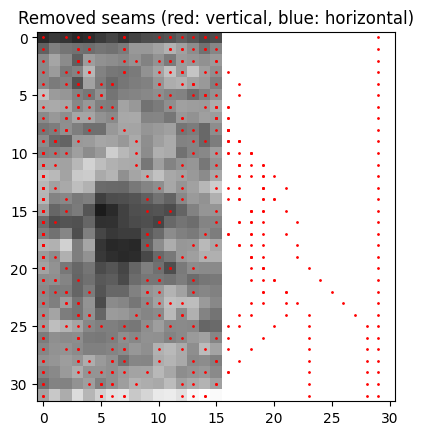

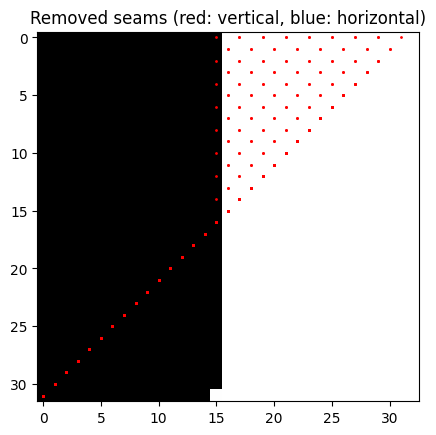

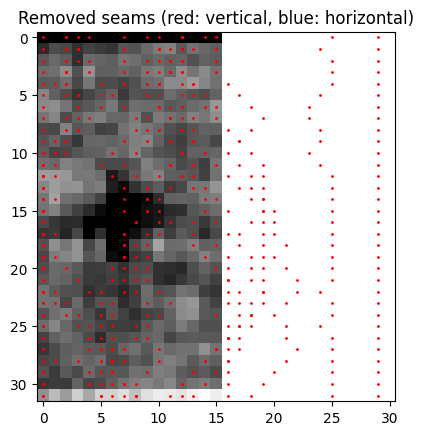

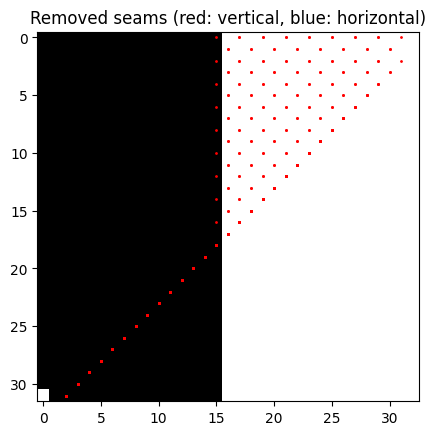

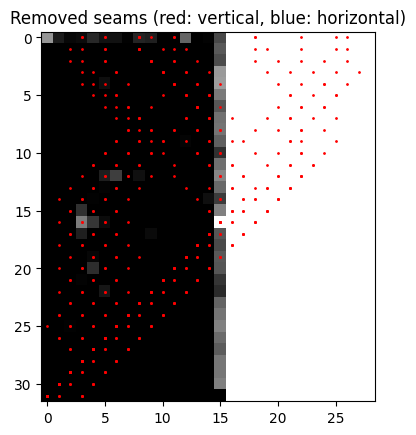

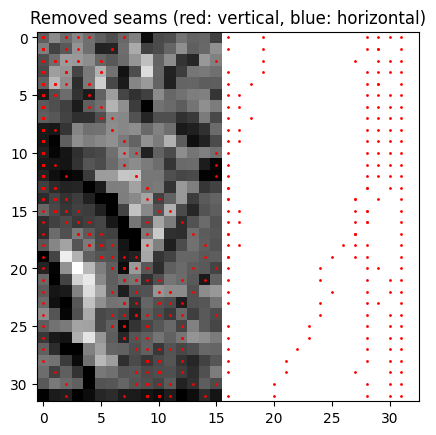

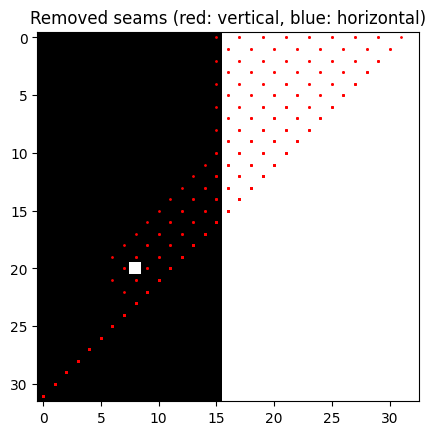

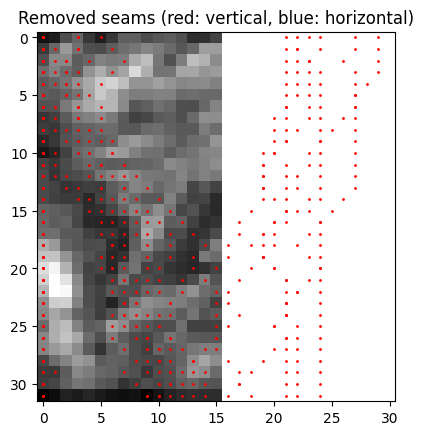

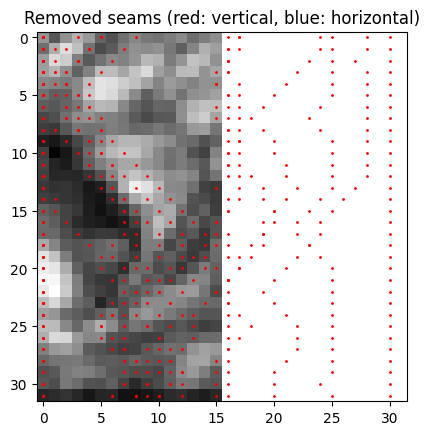

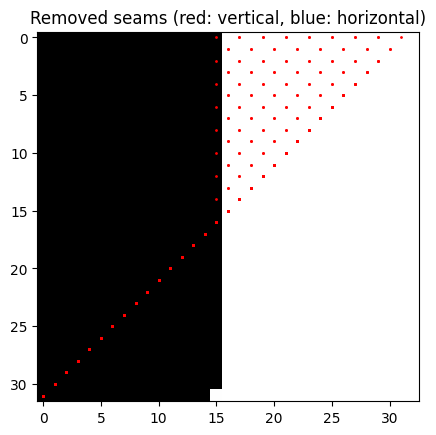

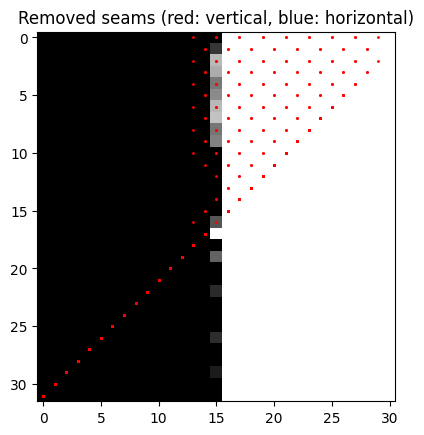

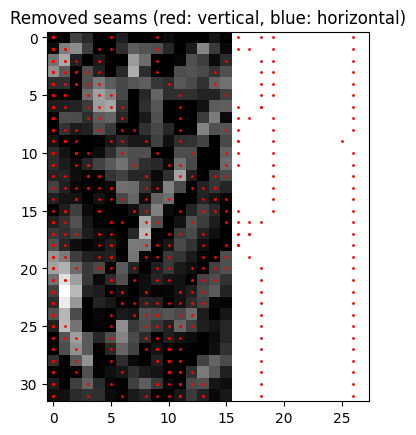

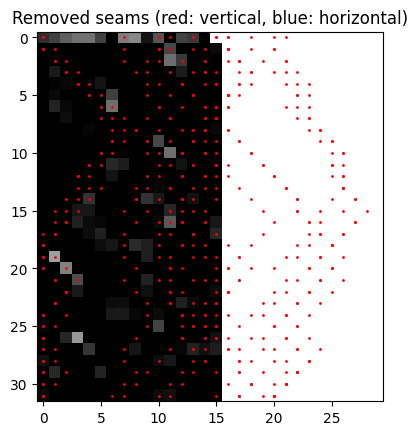

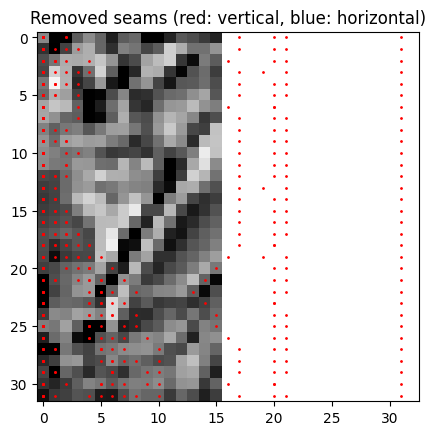

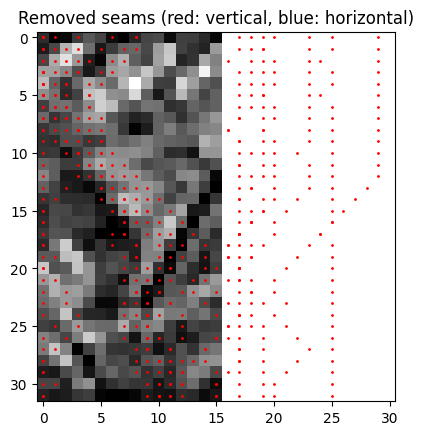

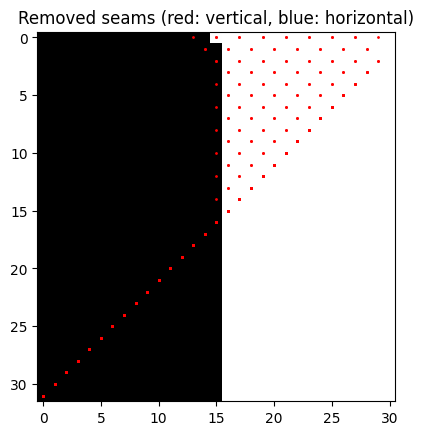

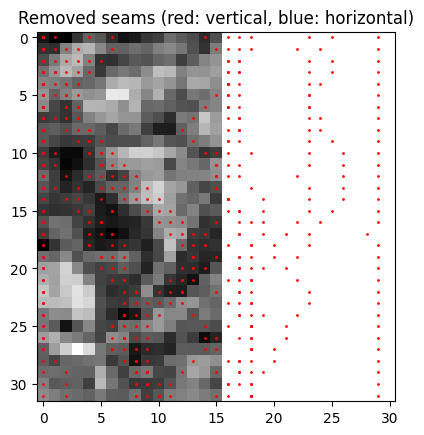

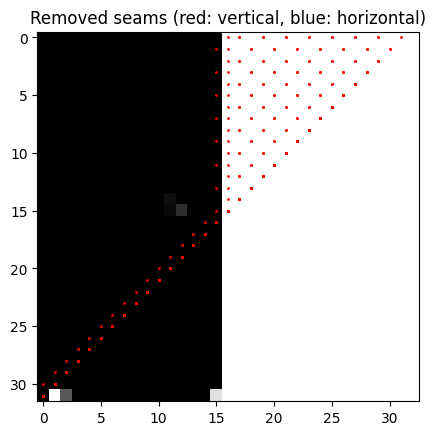

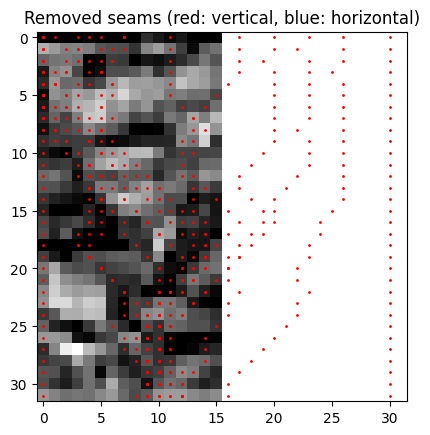

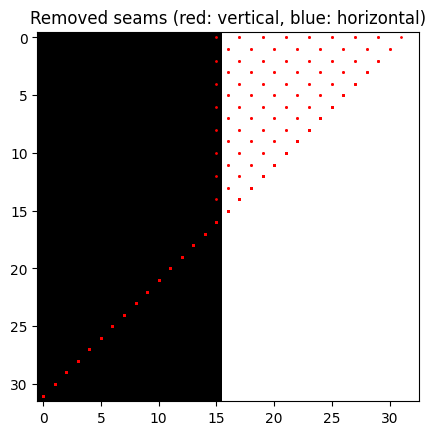

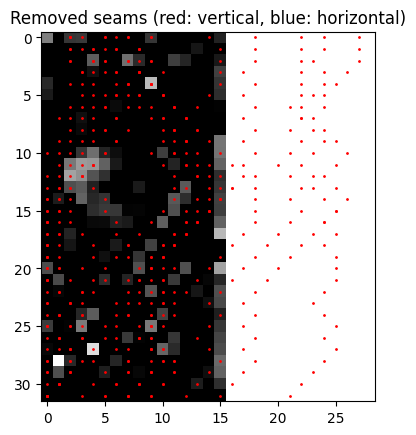

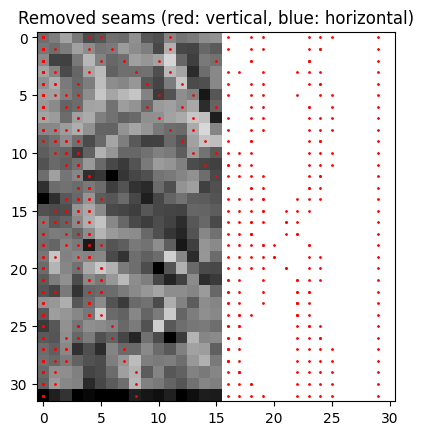

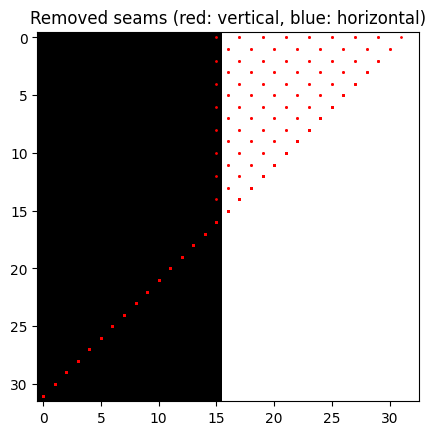

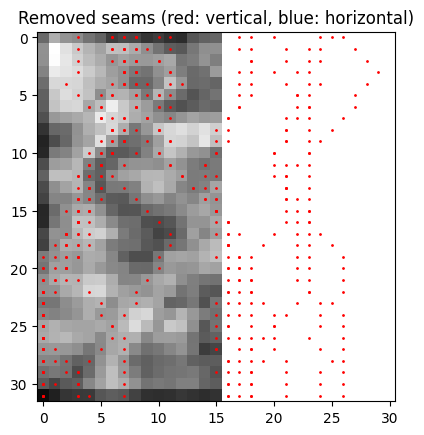

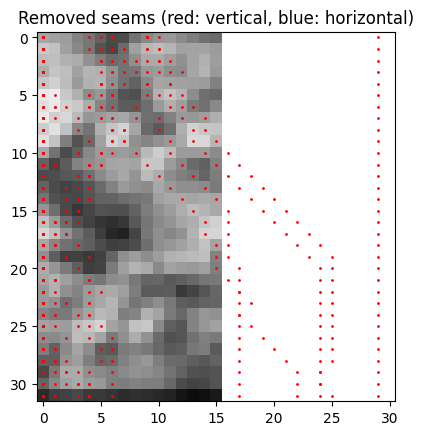

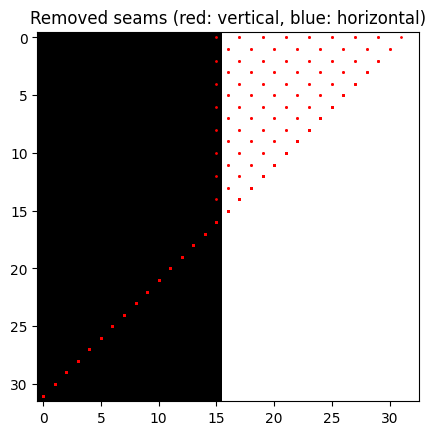

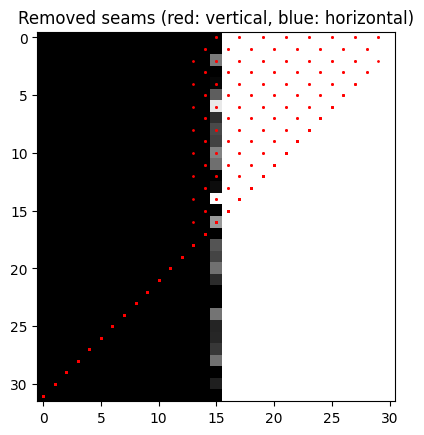

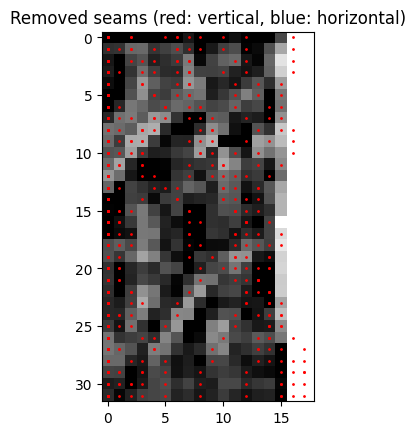

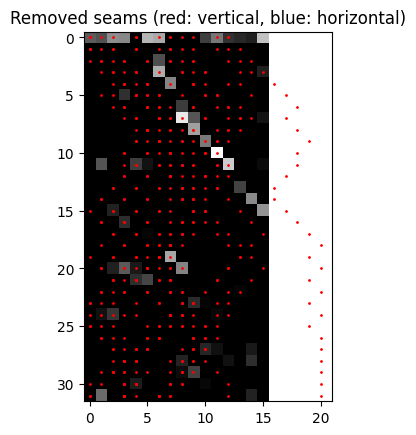

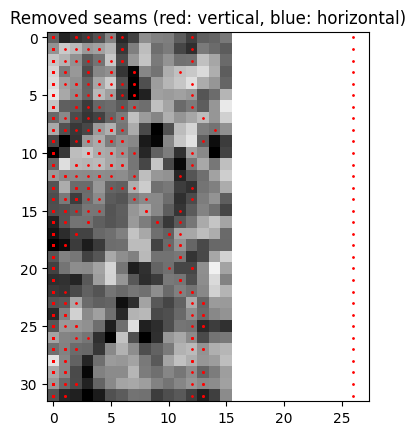

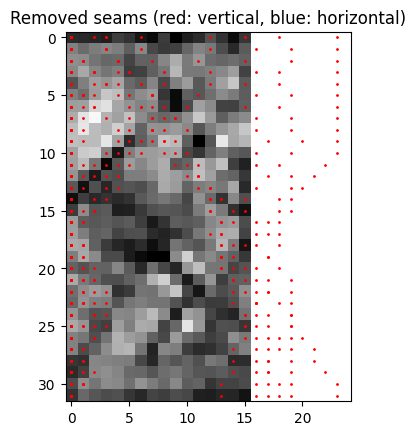

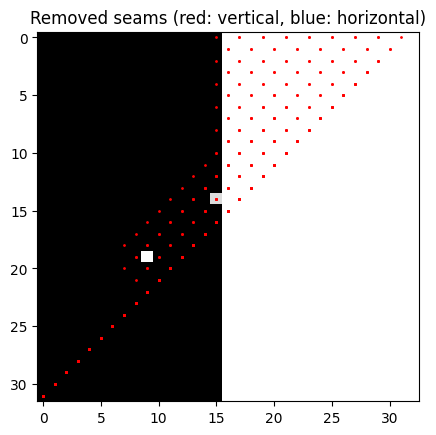

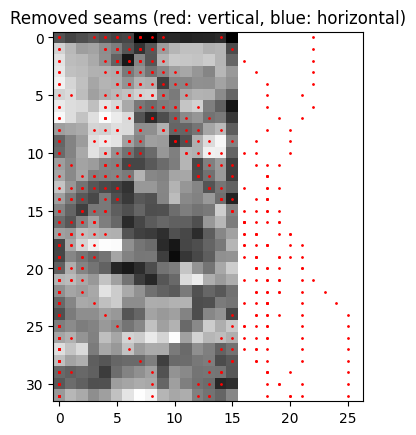

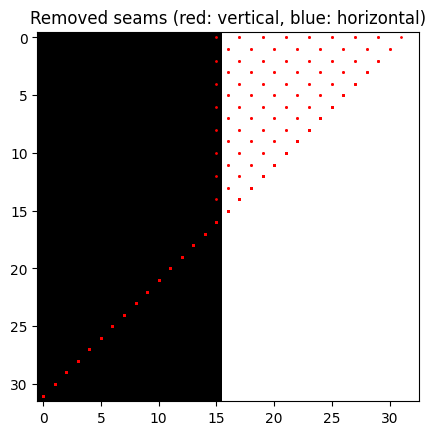

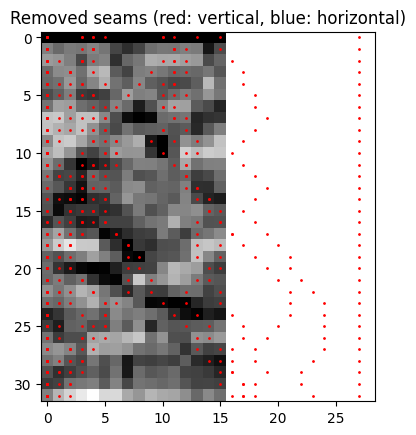

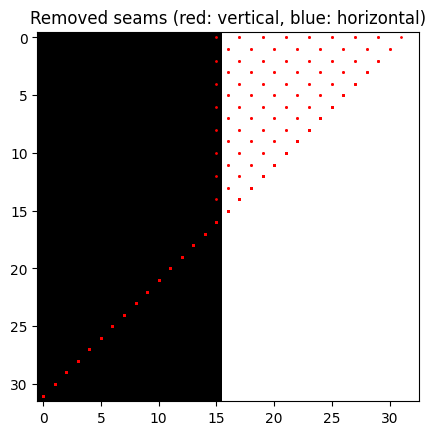

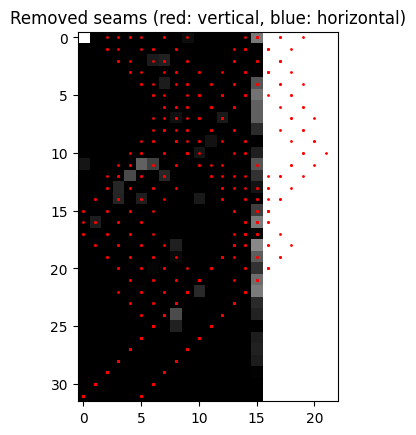

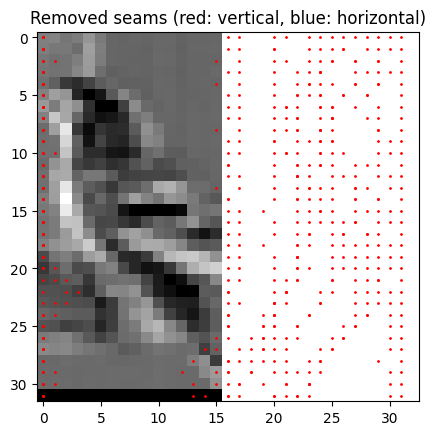

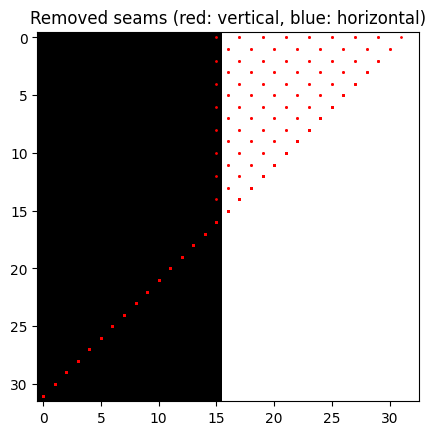

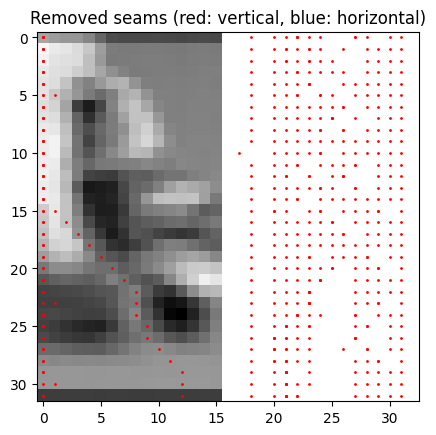

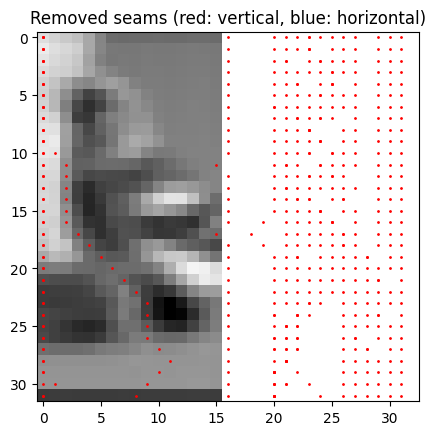

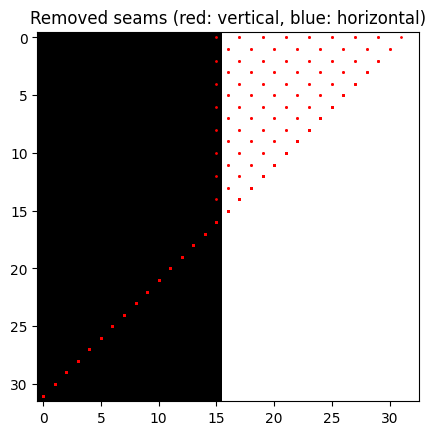

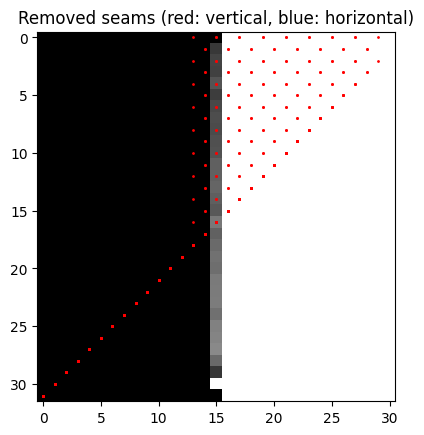

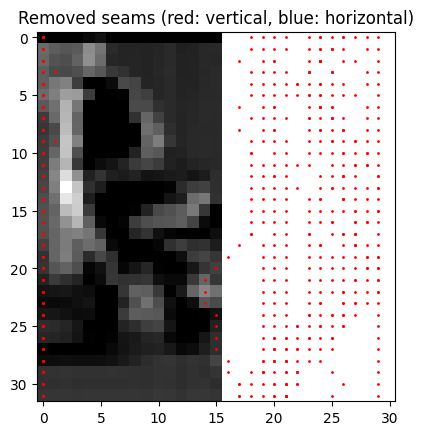

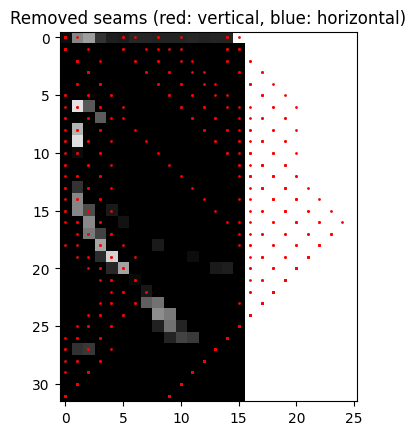

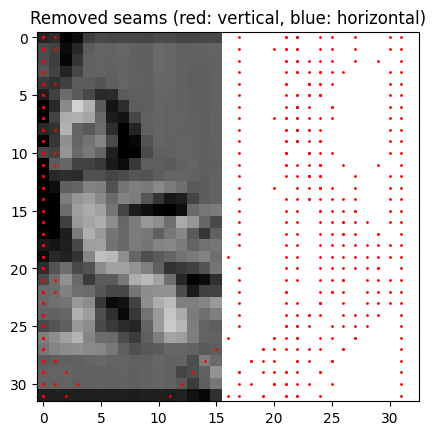

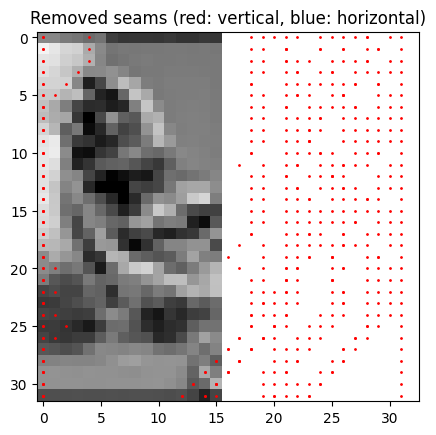

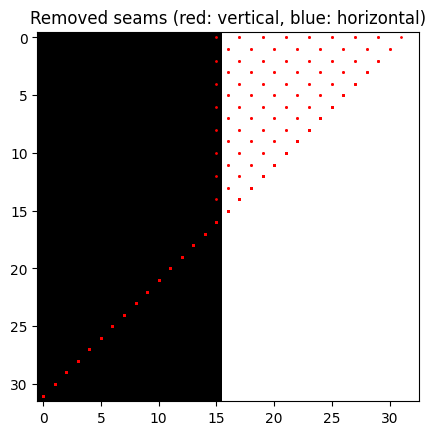

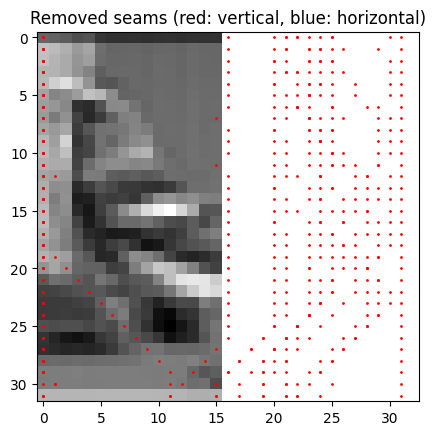

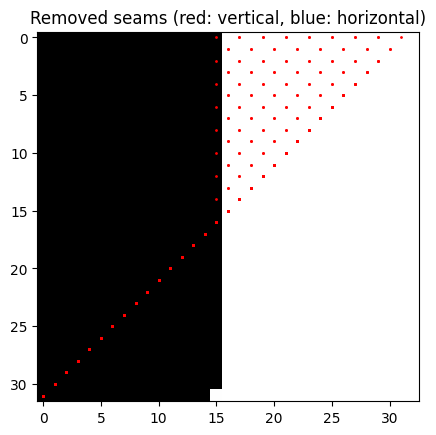

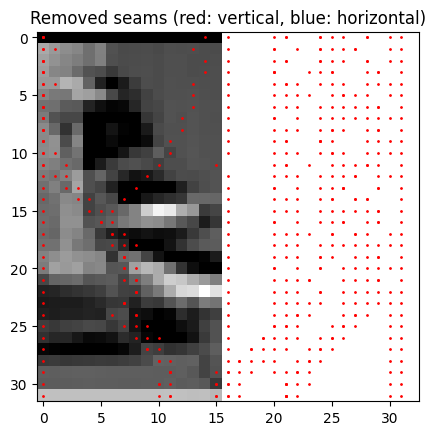

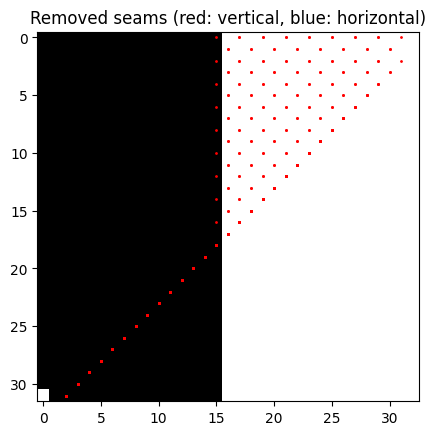

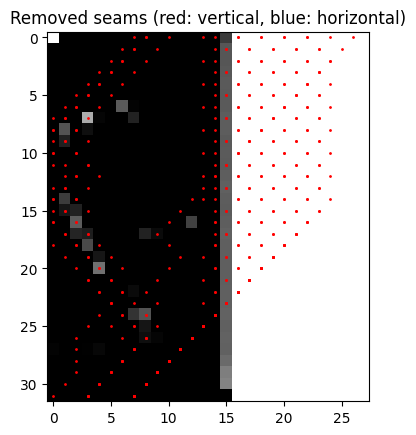

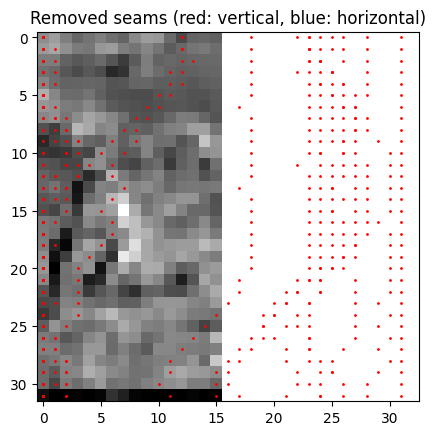

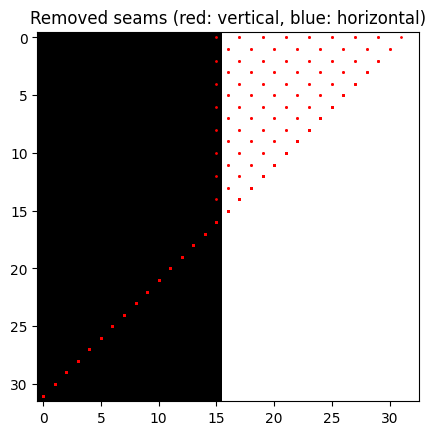

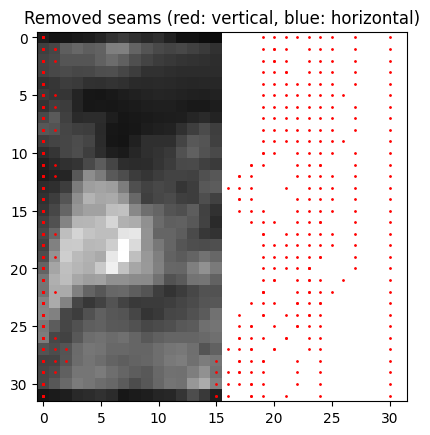

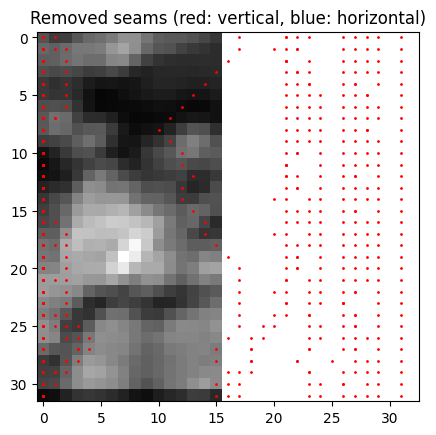

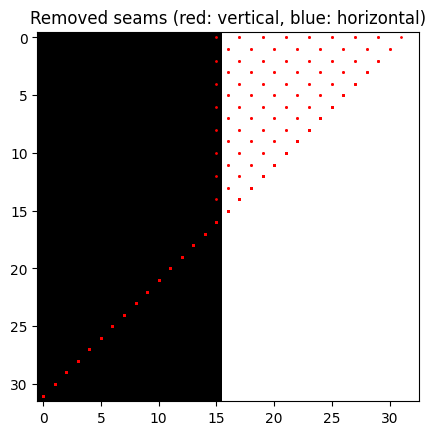

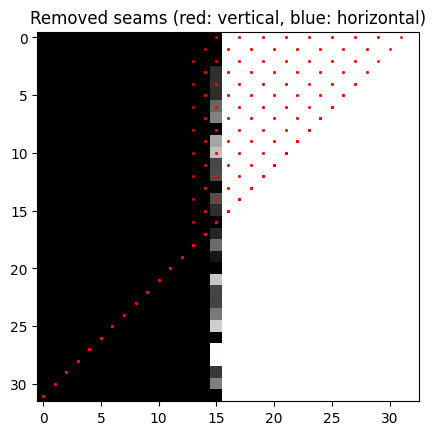

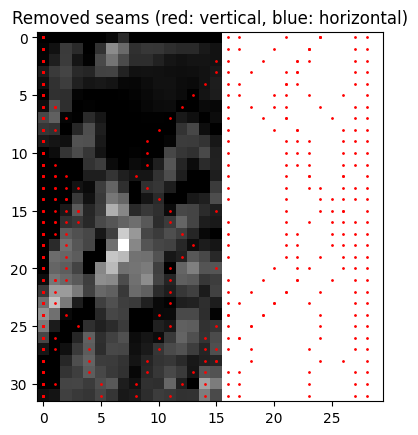

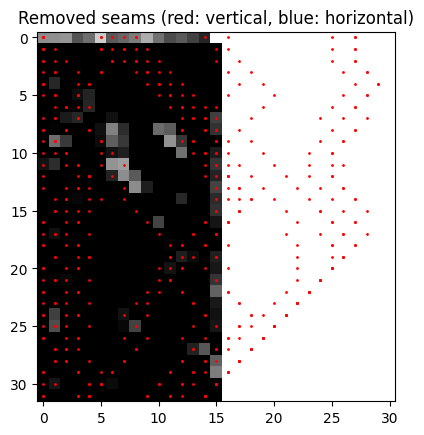

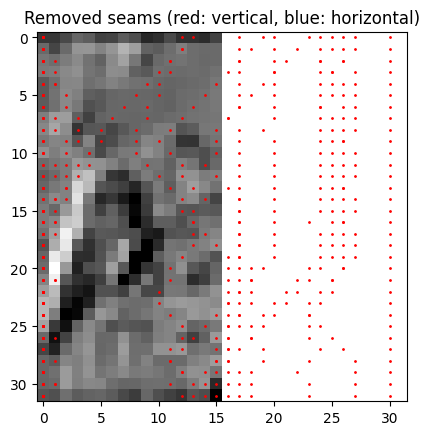

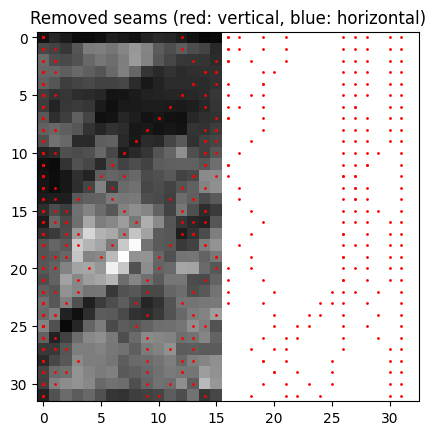

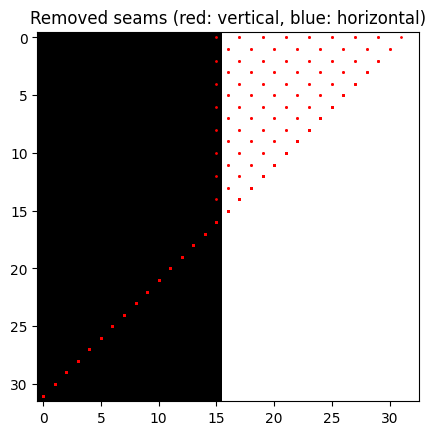

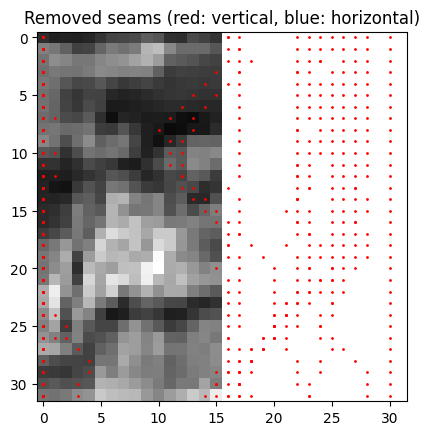

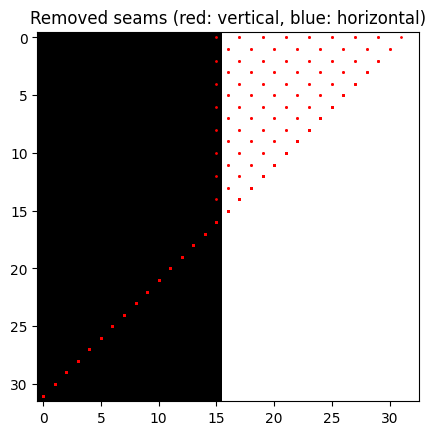

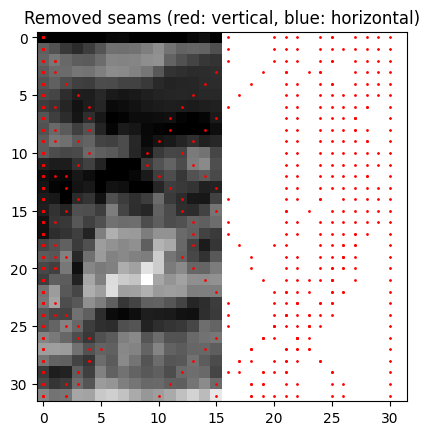

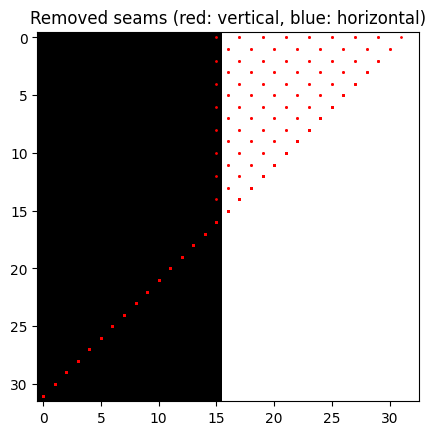

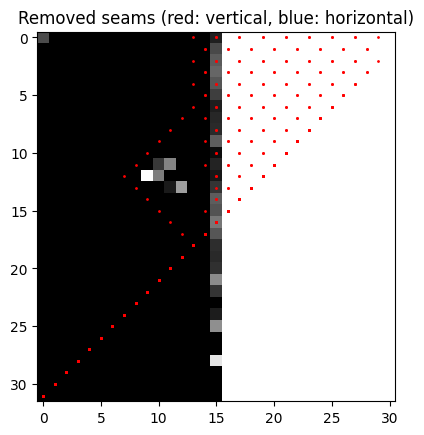

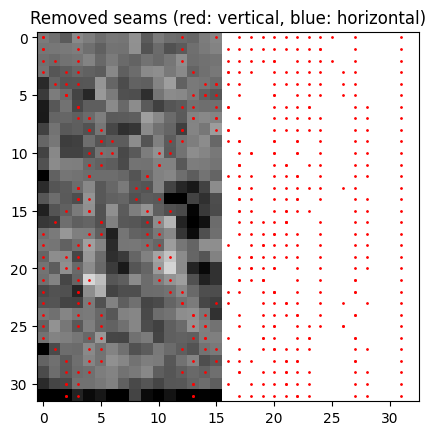

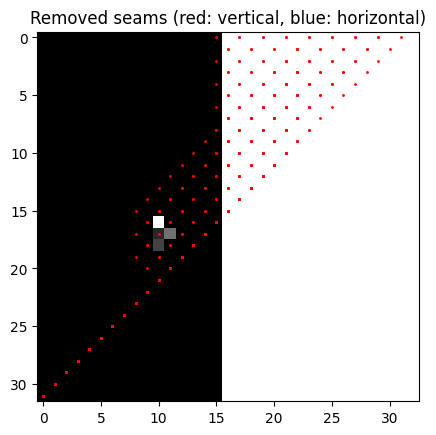

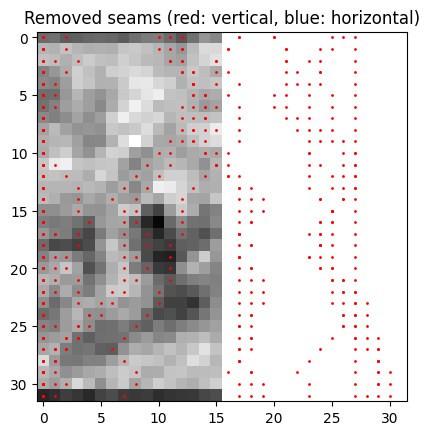

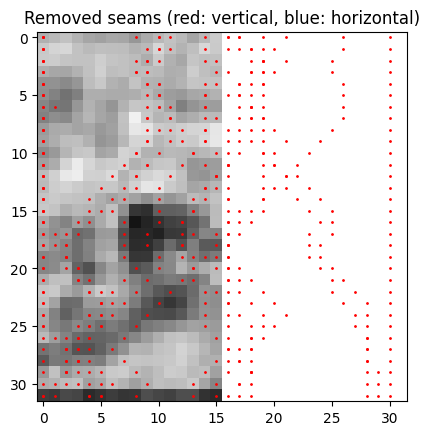

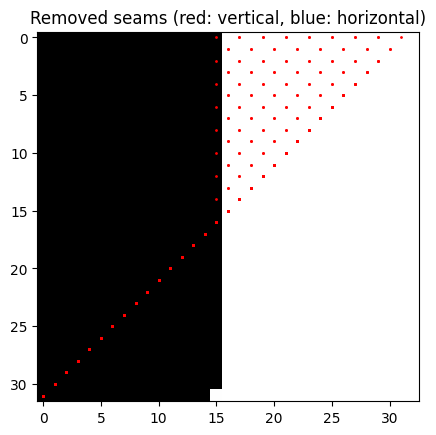

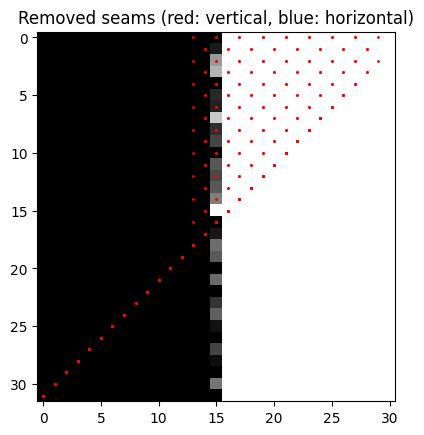

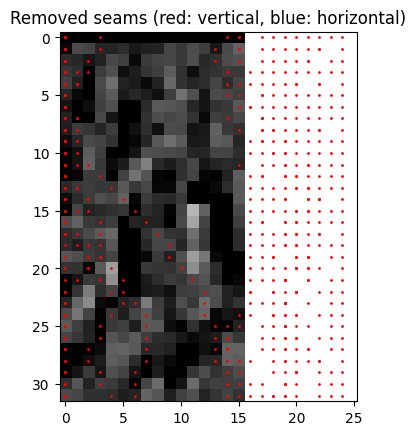

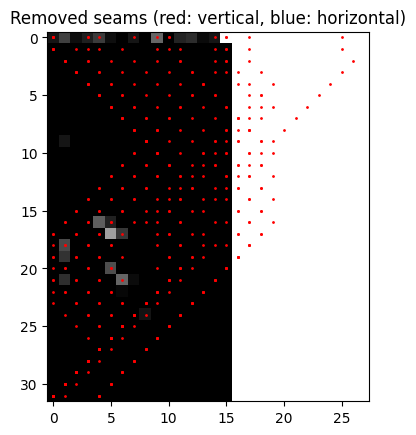

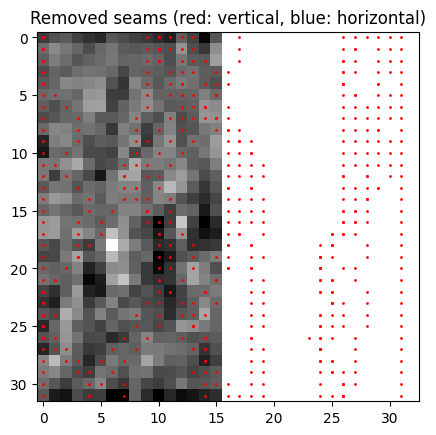

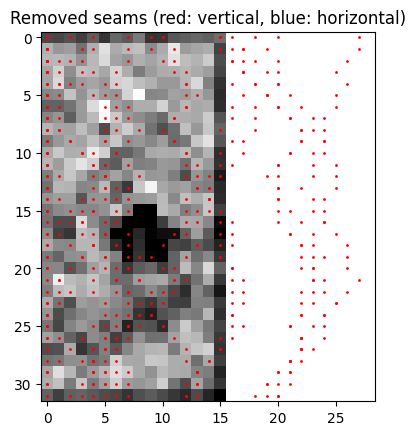

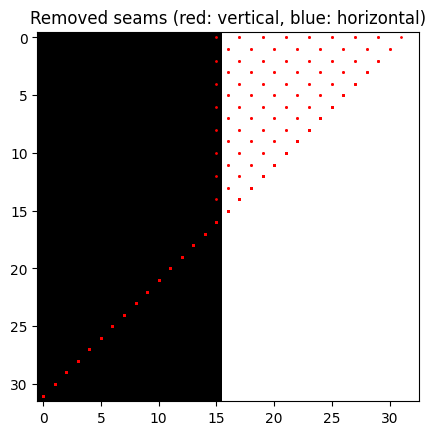

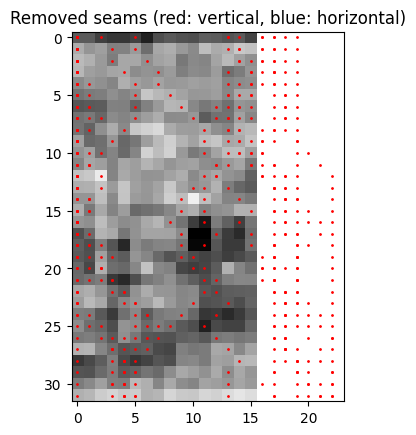

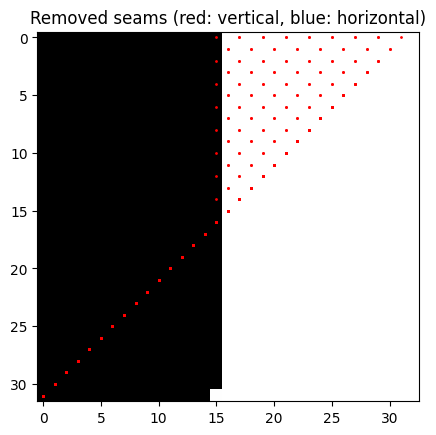

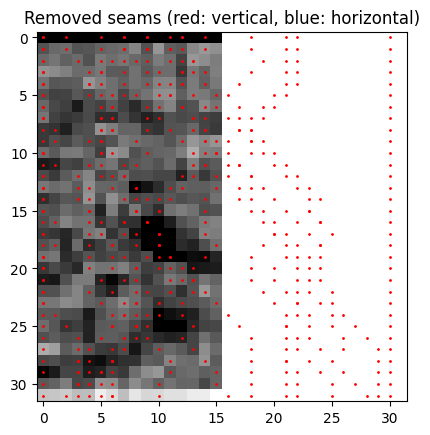

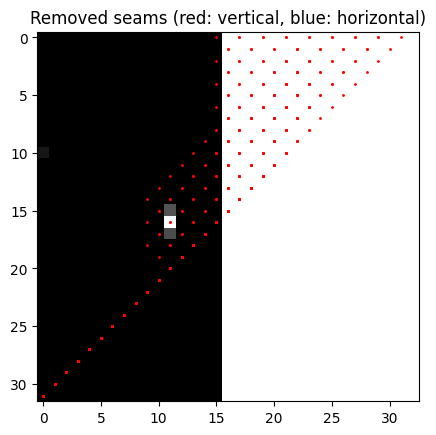

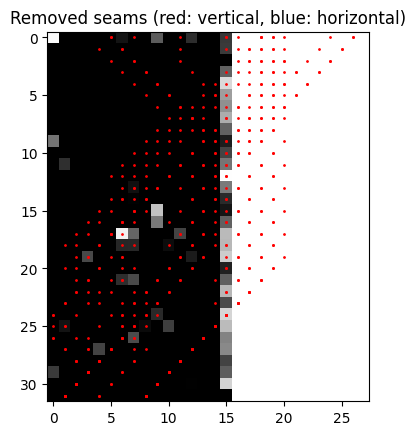

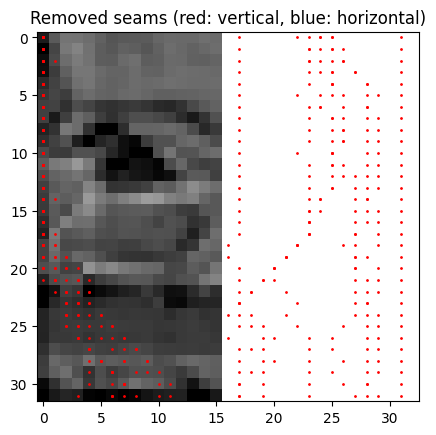

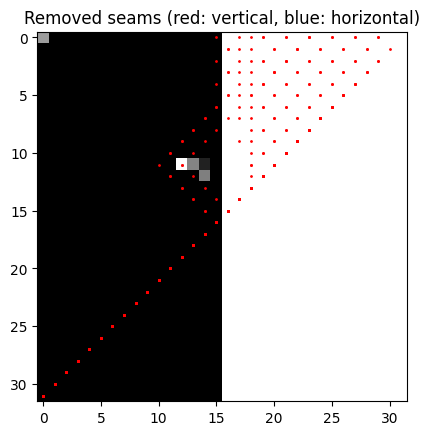

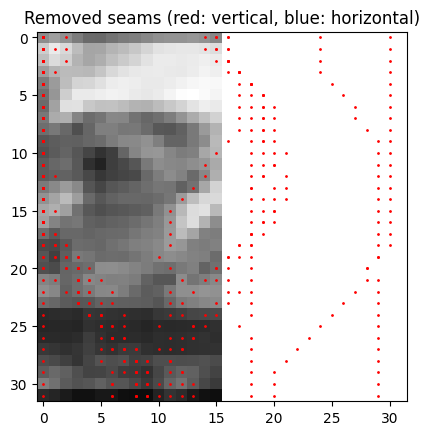

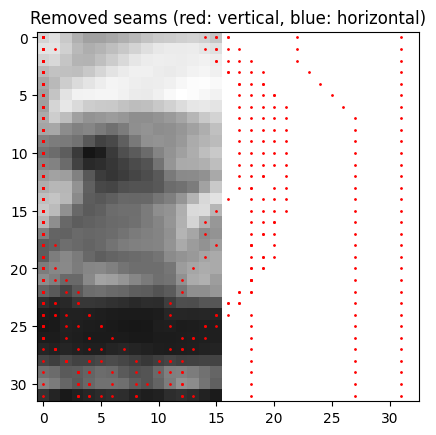

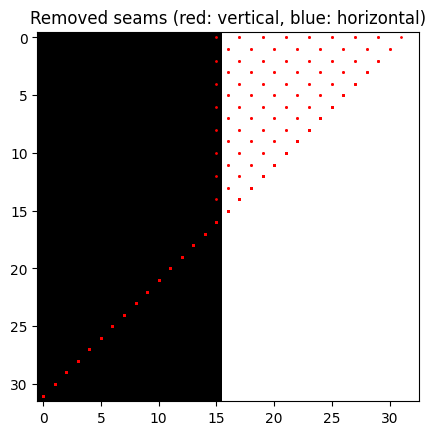

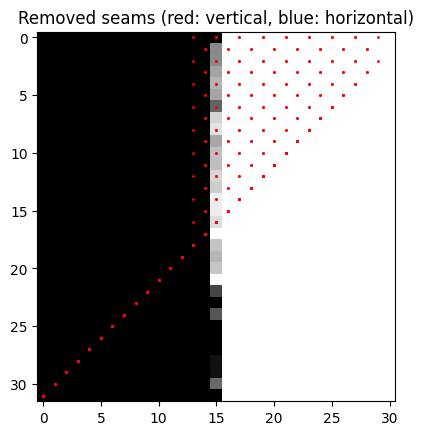

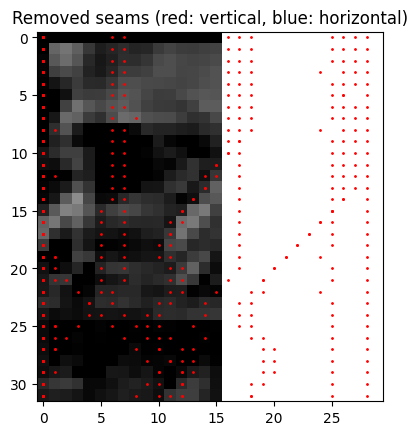

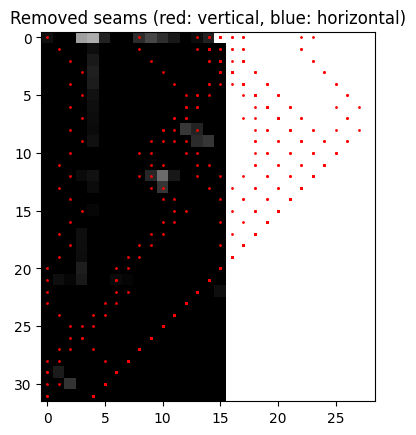

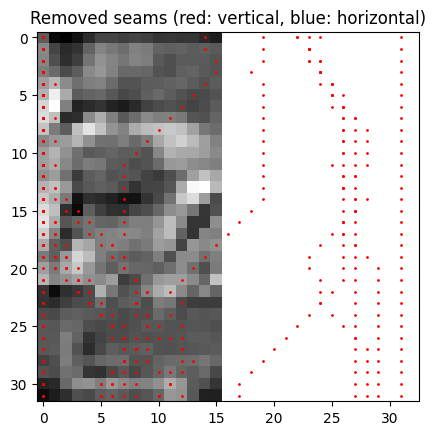

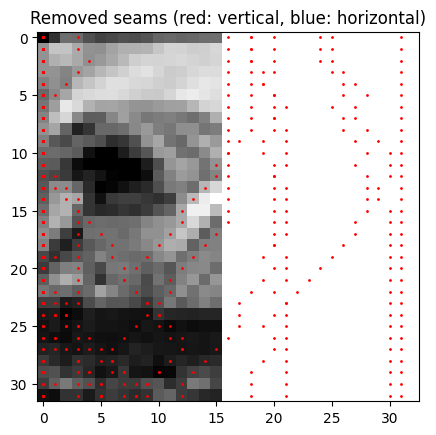

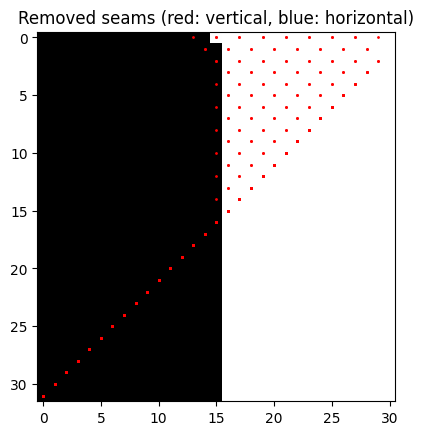

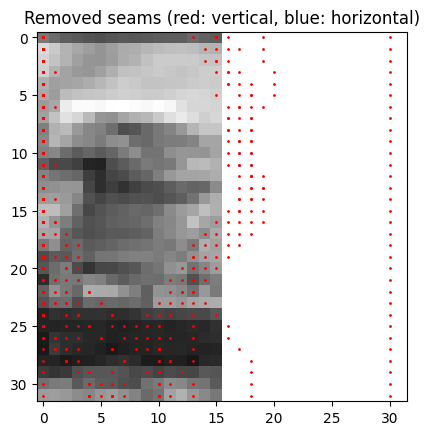

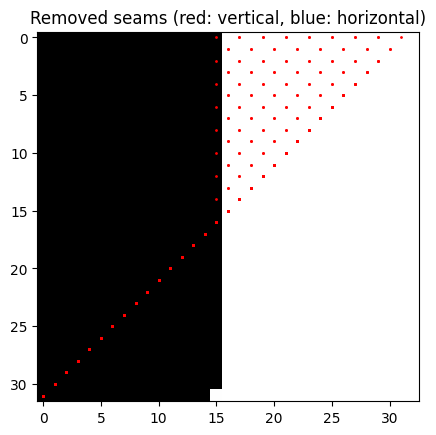

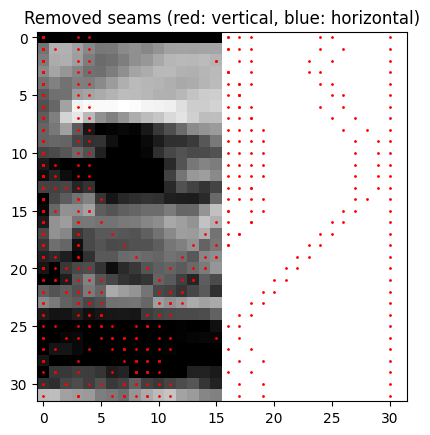

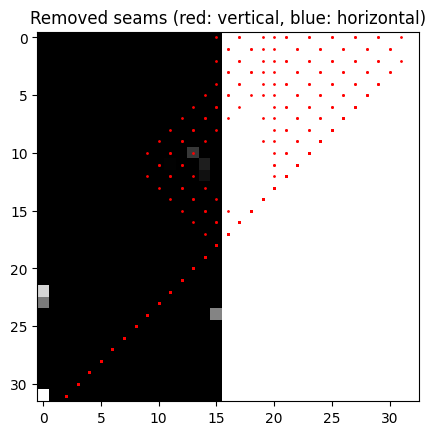

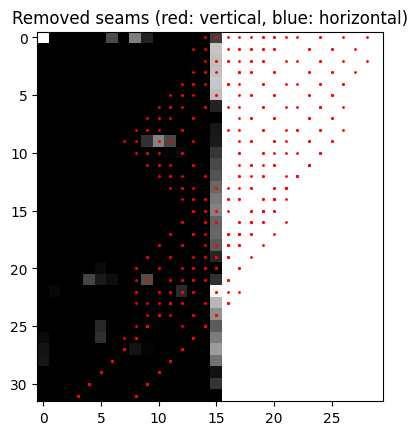

\n🔍 Rapport de classification pour SeamCarving :
                precision    recall  f1-score   support

      Bobolink       0.43      0.60      0.50         5
Indigo_Bunting       0.33      0.20      0.25         5

      accuracy                           0.40        10
     macro avg       0.38      0.40      0.38        10
  weighted avg       0.38      0.40      0.38        10

\n🔍 Rapport de classification pour MaxPooling :
                precision    recall  f1-score   support

      Bobolink       0.50      0.60      0.55         5
Indigo_Bunting       0.50      0.40      0.44         5

      accuracy                           0.50        10
     macro avg       0.50      0.50      0.49        10
  weighted avg       0.50      0.50      0.49        10



In [9]:
# Chargement des poids
criterion = nn.CrossEntropyLoss()

model_seam = CNNWithSeamCarving()
model_seam.load_state_dict(torch.load("models/cnn_seamcarving.pth", map_location=device))
evaluate_model(model_seam, "SeamCarving")

model_maxp = CNNWithMaxPooling()
model_maxp.load_state_dict(torch.load("models/cnn_maxpooling.pth", map_location=device))
evaluate_model(model_maxp, "MaxPooling")